# Reddit vs IMDb vs Rotten Tomatoes — Movie Rating Comparison

Comparing Reddit sentiment scores against IMDb ratings and Rotten Tomatoes scores across genres and regions.

**Data sources:**
- Reddit comments (44k+ comments, scored via VADER + TextBlob + RoBERTa blend)
- IMDb ratings from OMDB API
- Rotten Tomatoes scores from OMDB API
- Movie metadata from TMDB

## 1. Setup & Load Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
print("Libraries loaded!")

Libraries loaded!


In [13]:
import snowflake.connector
from dotenv import load_dotenv
import os

load_dotenv()

conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="RAW"
)

# load movie master (has IMDB + RT ratings)
movies = pd.read_sql("SELECT * FROM RAW.MOVIES_MASTER", conn)
print(f"Movies master: {len(movies)} movies")
print(f"Columns: {movies.columns.tolist()}")

conn.close()

Task was destroyed but it is pending!
task: <Task pending name='Task-95' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /opt/anaconda3/envs/moviepulse/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-96' coro=<_async_in_context.<locals>.preserve_context() running at /opt/anaconda3/envs/moviepulse/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/moviepulse/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-96' coro=<_async_in_context.<locals>.preserve_context() running at /opt/anaconda3/envs/moviepulse/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]>


Movies master: 571 movies
Columns: ['TMDB_ID', 'IMDB_ID', 'TITLE', 'YEAR', 'GENRE', 'REGION', 'IMDB_RATING', 'RT_SCORE', 'POPULARITY']


In [14]:
# load reddit movie scores from the sentiment analysis
reddit = pd.read_csv("data/reddit_movie_scores_v2.csv")
print(f"Reddit scores: {len(reddit)} movies")
reddit.head()

Reddit scores: 401 movies


,movie_name,reddit_score_v2,multi_avg,reddit_score_v1,total_comments,explicit_ratings,english_pct,positive_pct,negative_pct,score_diff
0,Mystic Christmas,8.46,10.000000,7.656667,3,0,100.0,100.0,0.0,0.80
1,Lost Ladies,8.15,8.355769,8.024038,52,2,98.1,84.6,7.7,0.13
2,Lucky Man,8.04,7.187500,8.607500,4,0,100.0,100.0,0.0,-0.57
3,Desire Lines,7.99,8.500000,7.760000,3,0,100.0,100.0,0.0,0.23
4,Hisaab Barabar,7.81,7.468750,8.085000,8,0,100.0,87.5,12.5,-0.28


## 2. Merge Reddit Scores with IMDb & RT

Joining on movie title. We need to clean up RT score (remove %) and normalize everything to the same scale.

In [15]:
# clean up column names for the join
movies.columns = [c.lower() for c in movies.columns]

# merge on title
df = reddit.merge(
    movies,
    left_on="movie_name",
    right_on="title",
    how="inner"
)

print(f"Matched {len(df)} movies out of {len(reddit)} Reddit-scored movies")
print(f"Lost {len(reddit) - len(df)} movies (no match in master table)")

Matched 401 movies out of 401 Reddit-scored movies
Lost 0 movies (no match in master table)


In [16]:
print(df.columns.tolist())

['movie_name', 'reddit_score_v2', 'multi_avg', 'reddit_score_v1', 'total_comments', 'explicit_ratings', 'english_pct', 'positive_pct', 'negative_pct', 'score_diff', 'tmdb_id', 'imdb_id', 'title', 'year', 'genre', 'region', 'imdb_rating', 'rt_score', 'popularity']


In [17]:
# clean RT score — remove % and convert to number
df["rt_score_num"] = df["rt_score"].str.replace("%", "").astype(float)

# normalize everything to 1-10 scale for fair comparison
# IMDb is already 1-10
# RT is 0-100, convert to 1-10
# Reddit is already 1-10

df["rt_score_10"] = (df["rt_score_num"] / 10).round(2)  # 88% -> 8.8
df["imdb_rating"] = df["imdb_rating"].astype(float)
df = df.rename(columns={"reddit_score_v2": "reddit_score"})

# keep only movies where we have all 3 scores
# require RT only for Hollywood (they always have it)
# bollywood/kollywood often dont have RT scores so just need Reddit + IMDb
hollywood = df[df["region"] == "Hollywood"].dropna(subset=["reddit_score", "imdb_rating", "rt_score_10"])
others = df[df["region"] != "Hollywood"].dropna(subset=["reddit_score", "imdb_rating"])
df = pd.concat([hollywood, others])
print(f"Movies with ratings: {len(df)} ({len(hollywood)} Hollywood, {len(others)} regional)")
print(f"Movies with all 3 ratings: {len(df)}")
print()

# quick look at the data
df[["movie_name", "reddit_score", "imdb_rating", "rt_score_10", "genre", "region", "total_comments"]].head(10)

Movies with ratings: 364 (135 Hollywood, 229 regional)
Movies with all 3 ratings: 364



,movie_name,reddit_score,imdb_rating,rt_score_10,genre,region,total_comments
3,Desire Lines,7.99,7.3,8.2,"Documentary, Drama",Hollywood,3
5,Rental Family,7.81,7.6,8.7,"Comedy, Drama",Hollywood,200
11,The Wild Robot,7.28,8.2,9.7,"Animation, Adventure, Family",Hollywood,200
17,Superman,7.02,7.1,8.3,"Action, Adventure, Sci-Fi",Hollywood,142
19,Train Dreams,7.00,7.5,9.5,Drama,Hollywood,200
21,Kung Fu Panda 4,6.96,6.3,7.1,"Animation, Action, Adventure",Hollywood,200
26,Nobody 2,6.89,6.3,7.6,"Action, Comedy, Crime",Hollywood,199
29,Abigail,6.85,6.5,8.3,"Action, Comedy, Crime",Hollywood,200
30,Mission: Impossible - Dead Reckoning Part One,6.85,7.6,9.6,"Action, Adventure, Thriller",Hollywood,200
32,The Bad Guys 2,6.81,7.0,8.7,"Animation, Action, Adventure",Hollywood,200


## 3. Overall Comparison — Reddit vs IMDb vs RT

In [18]:
# basic stats
print("=== Rating Summary ===")
print(f"Reddit  — Mean: {df['reddit_score'].mean():.2f}, Median: {df['reddit_score'].median():.2f}, Std: {df['reddit_score'].std():.2f}")
print(f"IMDb    — Mean: {df['imdb_rating'].mean():.2f}, Median: {df['imdb_rating'].median():.2f}, Std: {df['imdb_rating'].std():.2f}")
rt_valid = df["rt_score_10"].dropna()
print(f"RT (/10)— Mean: {rt_valid.mean():.2f}, Median: {rt_valid.median():.2f}, Std: {rt_valid.std():.2f} ({len(rt_valid)} movies with RT)")


=== Rating Summary ===
Reddit  — Mean: 5.76, Median: 5.74, Std: 0.76
IMDb    — Mean: 6.38, Median: 6.50, Std: 1.24
RT (/10)— Mean: 6.24, Median: 6.70, Std: 2.70 (232 movies with RT)


In [19]:
# correlations — only use movies that have both scores for each pair
print("=== Correlations ===")
print(f"Reddit vs IMDb:  {df['reddit_score'].corr(df['imdb_rating']):.3f}")

# RT correlations only for movies that have RT scores
rt_df = df.dropna(subset=["rt_score_10"])
print(f"Reddit vs RT:    {rt_df['reddit_score'].corr(rt_df['rt_score_10']):.3f} ({len(rt_df)} movies)")
print(f"IMDb vs RT:      {rt_df['imdb_rating'].corr(rt_df['rt_score_10']):.3f} ({len(rt_df)} movies)")
print()

# statistical significance
r_imdb, p_imdb = stats.pearsonr(df["reddit_score"], df["imdb_rating"])
r_rt, p_rt = stats.pearsonr(rt_df["reddit_score"], rt_df["rt_score_10"])
r_imdb_rt, p_imdb_rt = stats.pearsonr(rt_df["imdb_rating"], rt_df["rt_score_10"])

print(f"Reddit vs IMDb:  r={r_imdb:.3f}, p={p_imdb:.4f} {'✅ Significant' if p_imdb < 0.05 else '❌ Not significant'}")
print(f"Reddit vs RT:    r={r_rt:.3f}, p={p_rt:.4f} {'✅ Significant' if p_rt < 0.05 else '❌ Not significant'}")
print(f"IMDb vs RT:      r={r_imdb_rt:.3f}, p={p_imdb_rt:.4f} {'✅ Significant' if p_imdb_rt < 0.05 else '❌ Not significant'}")


=== Correlations ===
Reddit vs IMDb:  0.355
Reddit vs RT:    0.418 (232 movies)
IMDb vs RT:      0.680 (232 movies)

Reddit vs IMDb:  r=0.355, p=0.0000 ✅ Significant
Reddit vs RT:    r=0.418, p=0.0000 ✅ Significant
IMDb vs RT:      r=0.680, p=0.0000 ✅ Significant


In [20]:
# only keep movies with enough Reddit data to be meaningful
min_comments = 20

df_filtered = df[df["total_comments"] >= min_comments]
print(f"Movies with {min_comments}+ comments: {len(df_filtered)}")
print(f"Dropped: {len(df) - len(df_filtered)} movies with too few comments")
print()

rt_filtered = df_filtered.dropna(subset=["rt_score_10"])
print("Correlations (filtered):")
print(f"  Reddit vs IMDb: {df_filtered['reddit_score'].corr(df_filtered['imdb_rating']):.3f}")
print(f"  Reddit vs RT:   {rt_filtered['reddit_score'].corr(rt_filtered['rt_score_10']):.3f} ({len(rt_filtered)} movies)")
print(f"  IMDb vs RT:     {rt_filtered['imdb_rating'].corr(rt_filtered['rt_score_10']):.3f}")


Movies with 20+ comments: 317
Dropped: 47 movies with too few comments

Correlations (filtered):
  Reddit vs IMDb: 0.398
  Reddit vs RT:   0.451 (222 movies)
  IMDb vs RT:     0.701


In [21]:
for min_c in [50, 100, 150, 200]:
    filtered = df[df["total_comments"] >= min_c]
    rt_filt = filtered.dropna(subset=["rt_score_10"])
    if len(filtered) >= 10:
        r_imdb = filtered["reddit_score"].corr(filtered["imdb_rating"])
        r_rt = rt_filt["reddit_score"].corr(rt_filt["rt_score_10"]) if len(rt_filt) >= 10 else float("nan")
        print(f"Min {min_c:3d} comments → {len(filtered):3d} movies | Reddit-IMDb: {r_imdb:.3f} | Reddit-RT: {r_rt:.3f} ({len(rt_filt)} w/ RT)")


Min  50 comments → 274 movies | Reddit-IMDb: 0.408 | Reddit-RT: 0.488 (207 w/ RT)
Min 100 comments → 230 movies | Reddit-IMDb: 0.405 | Reddit-RT: 0.518 (186 w/ RT)
Min 150 comments → 192 movies | Reddit-IMDb: 0.442 | Reddit-RT: 0.525 (165 w/ RT)
Min 200 comments → 126 movies | Reddit-IMDb: 0.465 | Reddit-RT: 0.583 (120 w/ RT)


## 4. Scatter Plots — Visual Correlation

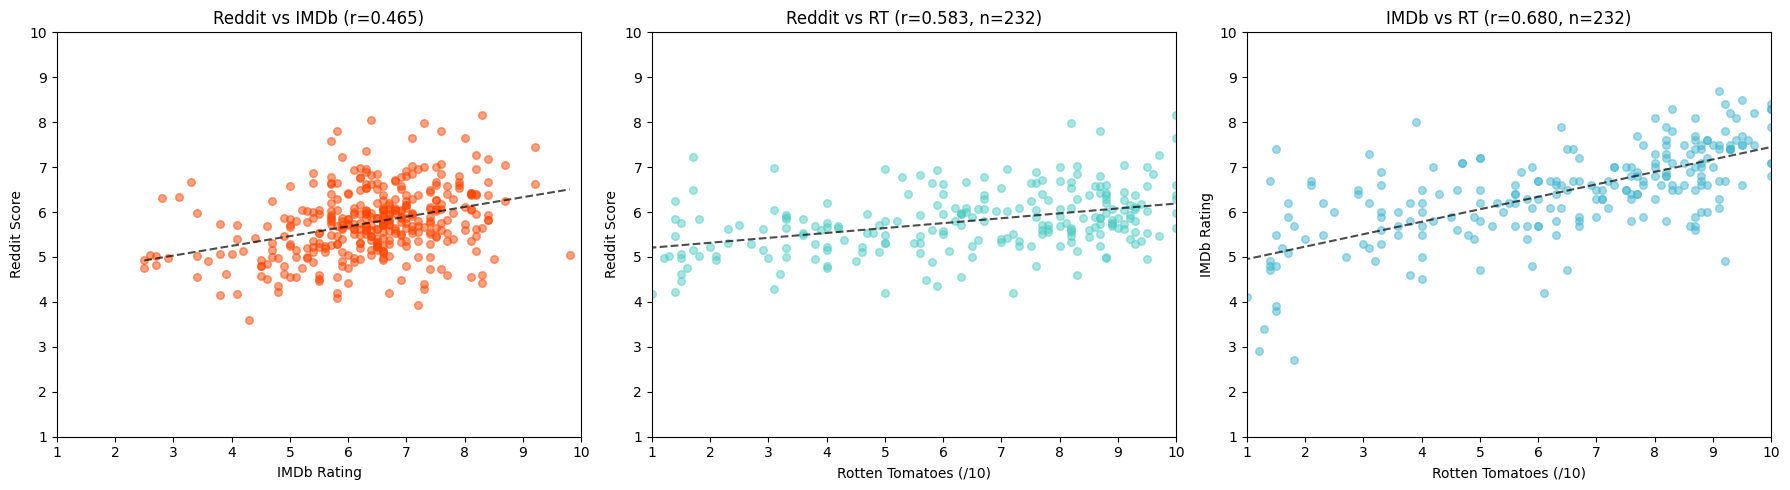

Saved!


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reddit vs IMDb (all movies)
axes[0].scatter(df["imdb_rating"], df["reddit_score"], alpha=0.5, c="#FF4500", s=30)
z = np.polyfit(df["imdb_rating"], df["reddit_score"], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df["imdb_rating"]), p(sorted(df["imdb_rating"])), "k--", alpha=0.7)
axes[0].set_xlabel("IMDb Rating")
axes[0].set_ylabel("Reddit Score")
axes[0].set_title(f"Reddit vs IMDb (r={r_imdb:.3f})")
axes[0].set_xlim(1, 10)
axes[0].set_ylim(1, 10)

# Reddit vs RT (only movies with RT scores)
rt_valid = df.dropna(subset=["rt_score_10"])
axes[1].scatter(rt_valid["rt_score_10"], rt_valid["reddit_score"], alpha=0.5, c="#4ECDC4", s=30)
z2 = np.polyfit(rt_valid["rt_score_10"], rt_valid["reddit_score"], 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(rt_valid["rt_score_10"]), p2(sorted(rt_valid["rt_score_10"])), "k--", alpha=0.7)
axes[1].set_xlabel("Rotten Tomatoes (/10)")
axes[1].set_ylabel("Reddit Score")
axes[1].set_title(f"Reddit vs RT (r={r_rt:.3f}, n={len(rt_valid)})")
axes[1].set_xlim(1, 10)
axes[1].set_ylim(1, 10)

# IMDb vs RT (only movies with RT scores)
axes[2].scatter(rt_valid["rt_score_10"], rt_valid["imdb_rating"], alpha=0.5, c="#45B7D1", s=30)
z3 = np.polyfit(rt_valid["rt_score_10"], rt_valid["imdb_rating"], 1)
p3 = np.poly1d(z3)
axes[2].plot(sorted(rt_valid["rt_score_10"]), p3(sorted(rt_valid["rt_score_10"])), "k--", alpha=0.7)
axes[2].set_xlabel("Rotten Tomatoes (/10)")
axes[2].set_ylabel("IMDb Rating")
axes[2].set_title(f"IMDb vs RT (r={r_imdb_rt:.3f}, n={len(rt_valid)})")
axes[2].set_xlim(1, 10)
axes[2].set_ylim(1, 10)

plt.tight_layout()
plt.savefig("data/platform_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")


## 5. Biggest Disagreements

Which movies does Reddit rate very differently from IMDb and RT?

In [23]:
# difference between reddit and imdb
df["reddit_vs_imdb"] = (df["reddit_score"] - df["imdb_rating"]).round(2)
df["reddit_vs_rt"] = (df["reddit_score"] - df["rt_score_10"]).round(2)
df["abs_diff_imdb"] = abs(df["reddit_vs_imdb"])
df["abs_diff_rt"] = abs(df["reddit_vs_rt"])

print("=== Reddit rates HIGHER than IMDb (Reddit loves, IMDb meh) ===")
cols = ["movie_name", "reddit_score", "imdb_rating", "reddit_vs_imdb", "total_comments", "genre"]
print(df.sort_values("reddit_vs_imdb", ascending=False)[cols].head(10).to_string(index=False))

print()
print("=== Reddit rates LOWER than IMDb (Reddit hates, IMDb likes) ===")
print(df.sort_values("reddit_vs_imdb", ascending=True)[cols].head(10).to_string(index=False))

=== Reddit rates HIGHER than IMDb (Reddit loves, IMDb meh) ===
                movie_name  reddit_score  imdb_rating  reddit_vs_imdb  total_comments                    genre
1920: Horrors of the Heart          6.32          2.8            3.52              49            Drama, Horror
                   Ruslaan          6.68          3.3            3.38              12         Action, Thriller
                     Japan          6.33          3.1            3.23             109    Action, Comedy, Crime
                      Kick          5.98          3.4            2.58             158    Action, Comedy, Drama
            Chandramukhi 2          5.05          2.6            2.45             199    Action, Comedy, Drama
                  Baaghi 4          4.93          2.5            2.43             200  Action, Drama, Thriller
                  Ganapath          5.03          2.7            2.33             200    Action, Drama, Sci-Fi
         War of the Worlds          4.75         

In [24]:
# RT comparisons — only for movies that have RT scores
rt_only = df.dropna(subset=["rt_score_10"])
print(f"Movies with RT scores: {len(rt_only)}")
print()
print("=== Reddit rates HIGHER than RT ===")
cols_rt = ["movie_name", "reddit_score", "rt_score_10", "reddit_vs_rt", "total_comments", "genre"]
print(rt_only.sort_values("reddit_vs_rt", ascending=False)[cols_rt].head(10).to_string(index=False))
print()
print("=== Reddit rates LOWER than RT ===")
print(rt_only.sort_values("reddit_vs_rt", ascending=True)[cols_rt].head(10).to_string(index=False))


Movies with RT scores: 232

=== Reddit rates HIGHER than RT ===
                    movie_name  reddit_score  rt_score_10  reddit_vs_rt  total_comments                       genre
      Auron Mein Kahan Dum Tha          6.26          0.0          6.26             191        Action, Crime, Drama
                        Sukhee          7.23          1.7          5.53               3               Comedy, Drama
                         Siren          5.47          0.0          5.47              55     Action, Crime, Thriller
Jewel Thief - The Heist Begins          5.71          0.5          5.21             104 Action, Adventure, Thriller
  Kisi Ka Bhai... Kisi Ki Jaan          5.06          0.0          5.06             200       Action, Comedy, Drama
 Crakk: Jeetega... Toh Jiyegaa          6.24          1.4          4.84              26     Action, Sport, Thriller
                        Apurva          6.50          1.7          4.80              30             Drama, Thriller
        

## 6. Comparison by Genre

Do certain genres get rated differently across platforms?

In [25]:
# movies can have multiple genres ("Action, Comedy, Drama")
# explode so each genre gets its own row
df["genre_list"] = df["genre"].str.split(", ")
genre_df = df.explode("genre_list")

# average rating per genre per platform
genre_avg = genre_df.groupby("genre_list").agg(
    reddit_avg = ("reddit_score", "mean"),
    imdb_avg = ("imdb_rating", "mean"),
    rt_avg = ("rt_score_10", "mean"),
    movie_count = ("movie_name", "count")
).reset_index()

# only genres with enough movies
genre_avg = genre_avg[genre_avg["movie_count"] >= 5]
genre_avg = genre_avg.sort_values("movie_count", ascending=False)

print(f"Genres with 5+ movies: {len(genre_avg)}")
genre_avg.round(2)

Genres with 5+ movies: 17


,genre_list,reddit_avg,imdb_avg,rt_avg,movie_count
7,Drama,5.77,6.46,6.30,195
0,Action,5.66,6.12,5.62,152
4,Comedy,5.87,6.38,6.52,103
19,Thriller,5.69,6.10,5.49,94
1,Adventure,5.71,6.43,6.48,72
5,Crime,5.85,6.48,6.05,68
11,Horror,5.59,5.90,6.61,43
16,Romance,5.79,6.43,6.45,32
17,Sci-Fi,5.74,5.87,6.07,25
14,Mystery,5.87,6.19,6.13,21


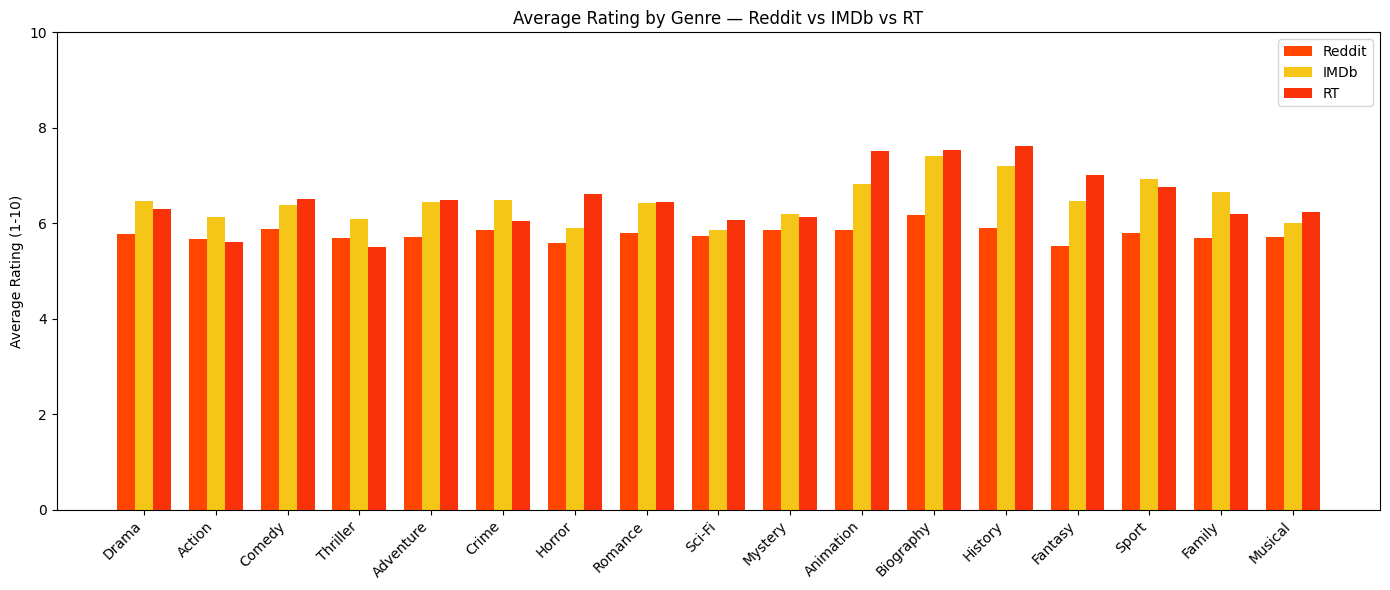

Saved!


In [26]:
# genre comparison chart
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(genre_avg))
width = 0.25

ax.bar([i - width for i in x], genre_avg["reddit_avg"], width, label="Reddit", color="#FF4500")
ax.bar(x, genre_avg["imdb_avg"], width, label="IMDb", color="#F5C518")
ax.bar([i + width for i in x], genre_avg["rt_avg"], width, label="RT", color="#FA320A")

ax.set_xticks(x)
ax.set_xticklabels(genre_avg["genre_list"], rotation=45, ha="right")
ax.set_ylabel("Average Rating (1-10)")
ax.set_title("Average Rating by Genre — Reddit vs IMDb vs RT")
ax.legend()
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig("data/genre_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [27]:
# which genres have the biggest gap between reddit and imdb/rt?
genre_avg["reddit_vs_imdb_gap"] = (genre_avg["reddit_avg"] - genre_avg["imdb_avg"]).round(2)
genre_avg["reddit_vs_rt_gap"] = (genre_avg["reddit_avg"] - genre_avg["rt_avg"]).round(2)

print("=== Genre Gaps (Reddit minus IMDb) ===")
print("Positive = Reddit rates higher, Negative = Reddit rates lower")
print(genre_avg[["genre_list", "reddit_avg", "imdb_avg", "reddit_vs_imdb_gap", "movie_count"]].sort_values("reddit_vs_imdb_gap", ascending=False).to_string(index=False))

=== Genre Gaps (Reddit minus IMDb) ===
Positive = Reddit rates higher, Negative = Reddit rates lower
genre_list  reddit_avg  imdb_avg  reddit_vs_imdb_gap  movie_count
    Sci-Fi    5.737200  5.868000               -0.13           25
   Musical    5.715714  6.000000               -0.28            7
    Horror    5.589302  5.902326               -0.31           43
   Mystery    5.867143  6.185714               -0.32           21
  Thriller    5.690957  6.096809               -0.41           94
    Action    5.660658  6.120395               -0.46          152
    Comedy    5.874175  6.384466               -0.51          103
     Crime    5.854412  6.476471               -0.62           68
   Romance    5.792500  6.428125               -0.64           32
     Drama    5.772615  6.464615               -0.69          195
 Adventure    5.709583  6.434722               -0.73           72
   Fantasy    5.522857  6.471429               -0.95           14
 Animation    5.868000  6.830000         

## 7. Comparison by Region

Hollywood vs Bollywood vs Kollywood vs Tollywood vs Mollywood — how do platforms compare across regional cinema?

In [28]:
region_avg = df.groupby("region").agg(
    reddit_avg = ("reddit_score", "mean"),
    imdb_avg = ("imdb_rating", "mean"),
    rt_avg = ("rt_score_10", "mean"),
    movie_count = ("movie_name", "count"),
    avg_comments = ("total_comments", "mean")
).reset_index()

region_avg = region_avg.sort_values("movie_count", ascending=False)
print("Average Ratings by Region:")
region_avg.round(2)

Average Ratings by Region:


,region,reddit_avg,imdb_avg,rt_avg,movie_count,avg_comments
1,Hollywood,5.81,6.60,7.35,135,180.97
0,Bollywood,5.86,6.17,4.66,124,105.33
2,Kollywood,5.59,6.35,4.78,105,90.27


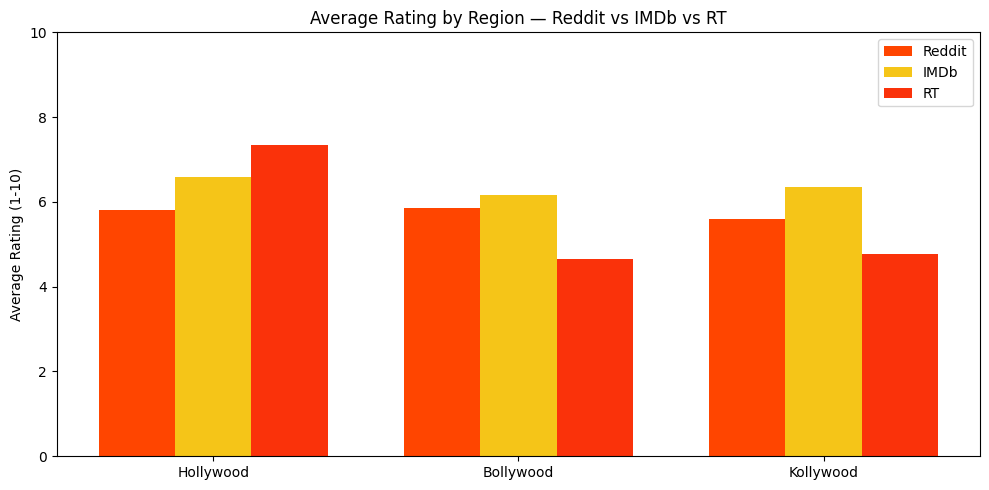

Saved!


In [29]:
# region comparison chart
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(region_avg))
width = 0.25

ax.bar([i - width for i in x], region_avg["reddit_avg"], width, label="Reddit", color="#FF4500")
ax.bar(x, region_avg["imdb_avg"], width, label="IMDb", color="#F5C518")
ax.bar([i + width for i in x], region_avg["rt_avg"], width, label="RT", color="#FA320A")

ax.set_xticks(x)
ax.set_xticklabels(region_avg["region"])
ax.set_ylabel("Average Rating (1-10)")
ax.set_title("Average Rating by Region — Reddit vs IMDb vs RT")
ax.legend()
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig("data/region_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 8. Correlation Heatmap

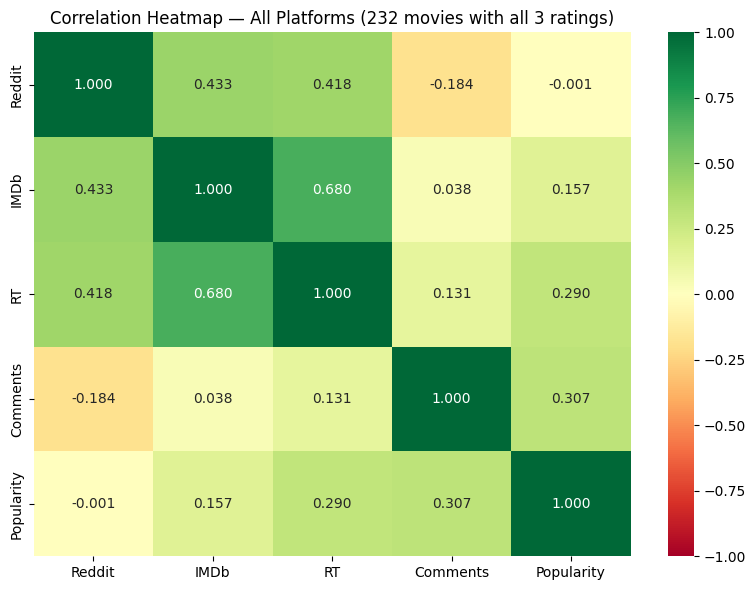

Saved!


In [30]:
# correlation matrix — use only movies with all scores for clean heatmap
corr_df = df.dropna(subset=["rt_score_10"])
corr_cols = ["reddit_score", "imdb_rating", "rt_score_10", "total_comments", "popularity"]
corr_matrix = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    xticklabels=["Reddit", "IMDb", "RT", "Comments", "Popularity"],
    yticklabels=["Reddit", "IMDb", "RT", "Comments", "Popularity"],
    ax=ax
)
ax.set_title(f"Correlation Heatmap — All Platforms ({len(corr_df)} movies with all 3 ratings)")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")


## 9. Rating Distribution Comparison

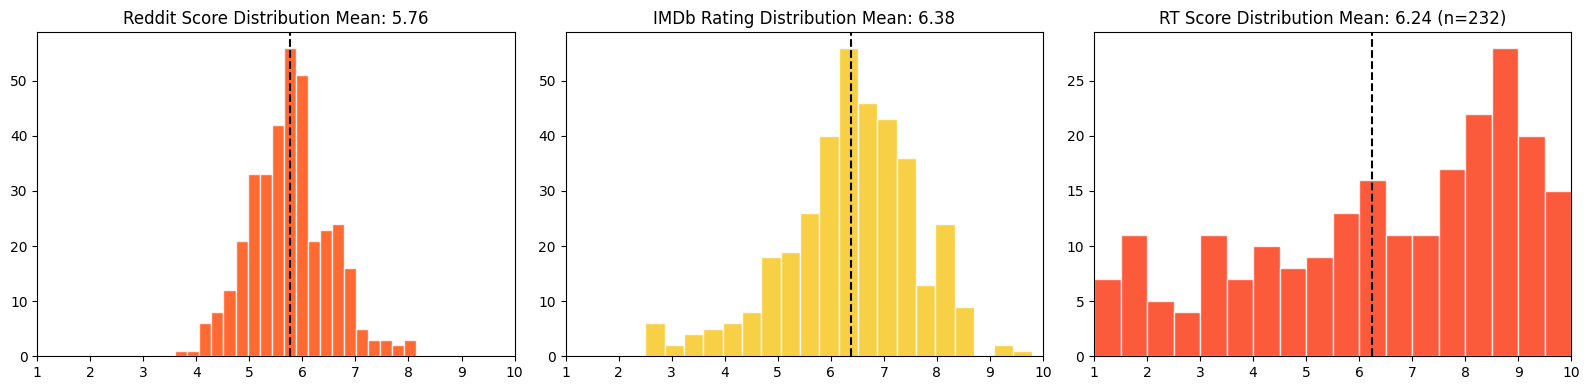

Saved!


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["reddit_score"], bins=20, color="#FF4500", alpha=0.8, edgecolor="white")
axes[0].set_title(f"Reddit Score Distribution Mean: {df['reddit_score'].mean():.2f}")
axes[0].set_xlim(1, 10)
axes[0].axvline(df["reddit_score"].mean(), color="black", linestyle="--")

axes[1].hist(df["imdb_rating"], bins=20, color="#F5C518", alpha=0.8, edgecolor="white")
axes[1].set_title(f"IMDb Rating Distribution Mean: {df['imdb_rating'].mean():.2f}")
axes[1].set_xlim(1, 10)
axes[1].axvline(df["imdb_rating"].mean(), color="black", linestyle="--")

rt_valid = df["rt_score_10"].dropna()
axes[2].hist(rt_valid, bins=20, color="#FA320A", alpha=0.8, edgecolor="white")
axes[2].set_title(f"RT Score Distribution Mean: {rt_valid.mean():.2f} (n={len(rt_valid)})")
axes[2].set_xlim(1, 10)
axes[2].axvline(rt_valid.mean(), color="black", linestyle="--")

plt.tight_layout()
plt.savefig("data/distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")


## 10. Reddit Sentiment Over Time

Does Reddit sentiment change over time? Looking at comment-level data with timestamps.

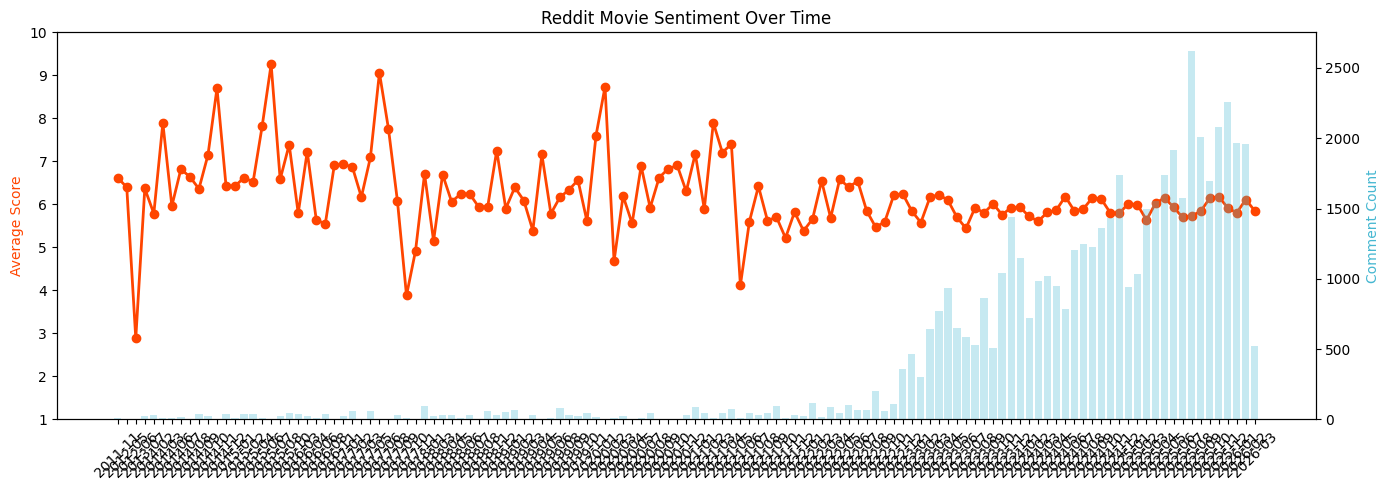

Saved!


In [32]:
# load full comment data with timestamps
comments = pd.read_csv("data/reddit_sentiment_scored.csv")
comments["comment_timestamp"] = pd.to_datetime(comments["comment_timestamp"])
comments["month"] = comments["comment_timestamp"].dt.to_period("M")

# average sentiment by month
monthly = comments.groupby("month").agg(
    avg_score = ("final_score", "mean"),
    comment_count = ("final_score", "count")
).reset_index()

monthly["month_str"] = monthly["month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(monthly["month_str"], monthly["avg_score"], "o-", color="#FF4500", linewidth=2, label="Avg Reddit Score")
ax1.set_ylabel("Average Score", color="#FF4500")
ax1.set_ylim(1, 10)

ax2 = ax1.twinx()
ax2.bar(monthly["month_str"], monthly["comment_count"], alpha=0.3, color="#45B7D1", label="Comment Volume")
ax2.set_ylabel("Comment Count", color="#45B7D1")

ax1.set_title("Reddit Movie Sentiment Over Time")
ax1.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.savefig("data/sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 11. Summary & Key Findings

In [33]:
print("="*60)
print("KEY FINDINGS")
print("="*60)
print()
print(f"Total movies compared: {len(df)}")
print(f"Total Reddit comments analyzed: {df['total_comments'].sum():,}")
rt_count = df["rt_score_10"].notna().sum()
print(f"Movies with RT scores: {rt_count}/{len(df)}")
print()
print("--- Overall ---")
print(f"Reddit avg: {df['reddit_score'].mean():.2f} | IMDb avg: {df['imdb_rating'].mean():.2f} | RT avg: {df['rt_score_10'].mean():.2f} (Hollywood mostly)")
print()
print("--- Correlations ---")
print(f"Reddit-IMDb: {df['reddit_score'].corr(df['imdb_rating']):.3f} (all {len(df)} movies)")
rt_df = df.dropna(subset=["rt_score_10"])
print(f"Reddit-RT:   {rt_df['reddit_score'].corr(rt_df['rt_score_10']):.3f} ({len(rt_df)} movies with RT)")
print(f"IMDb-RT:     {rt_df['imdb_rating'].corr(rt_df['rt_score_10']):.3f} ({len(rt_df)} movies with RT)")
print()
print("--- Interpretation ---")
r_val = df["reddit_score"].corr(df["imdb_rating"])
if r_val > 0.7:
    print("Reddit and IMDb are strongly correlated — similar opinions.")
elif r_val > 0.4:
    print("Reddit and IMDb are moderately correlated — some agreement but notable differences.")
elif r_val > 0.2:
    print("Reddit and IMDb are weakly correlated — Reddit users often disagree with IMDb.")
else:
    print("Reddit and IMDb show very little correlation — essentially independent rating systems.")
print()
print("--- Biggest Reddit vs IMDb disagreement ---")
biggest = df.loc[df["abs_diff_imdb"].idxmax()]
print(f"{biggest['movie_name']}: Reddit={biggest['reddit_score']:.1f}, IMDb={biggest['imdb_rating']:.1f} (diff={biggest['reddit_vs_imdb']:.1f})")


KEY FINDINGS

Total movies compared: 364
Total Reddit comments analyzed: 46,970
Movies with RT scores: 232/364

--- Overall ---
Reddit avg: 5.76 | IMDb avg: 6.38 | RT avg: 6.24 (Hollywood mostly)

--- Correlations ---
Reddit-IMDb: 0.355 (all 364 movies)
Reddit-RT:   0.418 (232 movies with RT)
IMDb-RT:     0.680 (232 movies with RT)

--- Interpretation ---
Reddit and IMDb are weakly correlated — Reddit users often disagree with IMDb.

--- Biggest Reddit vs IMDb disagreement ---
Ghich Pich: Reddit=5.0, IMDb=9.8 (diff=-4.8)


In [34]:
print(df.columns.tolist())

['movie_name', 'reddit_score', 'multi_avg', 'reddit_score_v1', 'total_comments', 'explicit_ratings', 'english_pct', 'positive_pct', 'negative_pct', 'score_diff', 'tmdb_id', 'imdb_id', 'title', 'year', 'genre', 'region', 'imdb_rating', 'rt_score', 'popularity', 'rt_score_num', 'rt_score_10', 'reddit_vs_imdb', 'reddit_vs_rt', 'abs_diff_imdb', 'abs_diff_rt', 'genre_list']


## 12. Save Final Comparison Data

In [35]:
# save the merged comparison data
output_cols = [
    "movie_name", "year", "genre", "region",
    "reddit_score", "multi_avg",
    "imdb_rating", "rt_score_10", "rt_score",
    "total_comments", "explicit_ratings", "positive_pct", "negative_pct",
    "reddit_vs_imdb", "reddit_vs_rt", "popularity"
]

final = df[output_cols].sort_values("total_comments", ascending=False)
final.to_csv("data/platform_comparison.csv", index=False)
print(f"Saved comparison for {len(final)} movies to data/platform_comparison.csv")
print()
print("All done! You now have:")
print("  - data/reddit_sentiment_scored.csv (44k scored comments)")
print("  - data/reddit_movie_scores.csv (209 movie scores)")
print("  - data/platform_comparison.csv (Reddit vs IMDb vs RT)")
print("  - Charts in data/ folder")

Saved comparison for 364 movies to data/platform_comparison.csv

All done! You now have:
  - data/reddit_sentiment_scored.csv (44k scored comments)
  - data/reddit_movie_scores.csv (209 movie scores)
  - data/platform_comparison.csv (Reddit vs IMDb vs RT)
  - Charts in data/ folder


## 13. Push to Snowflake (uncomment when ready)

In [36]:
conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="ANALYTICS"
)

from snowflake.connector.pandas_tools import write_pandas

push = final.copy()
push.columns = [c.upper() for c in push.columns]
scores = pd.read_csv("data/reddit_movie_scores_v2.csv")
scores.columns = [c.upper() for c in scores.columns]
write_pandas(conn, push, "PLATFORM_COMPARISON",
             database="MOVIE_ANALYTICS", schema="ANALYTICS",
             overwrite=True, auto_create_table=True)
print(f"Pushed {len(scores)} movie scores")
conn.close()
print("Pushed to Snowflake!")

Pushed 401 movie scores
Pushed to Snowflake!


In [37]:
import pandas as pd

df = pd.read_csv("data/reddit_raw_v3_backup.csv")
movies = pd.read_csv("data/movies_master.csv")

scraped = set(df["movie_name"].unique())
all_movies = set(movies["title"].unique())
missing = all_movies - scraped

print(f"Movies with 0 comments: {len(missing)}/{len(all_movies)}")
for m in sorted(missing):
    region = movies[movies["title"] == m]["region"].iloc[0]
    print(f"  {region:12s} | {m}")

Movies with 0 comments: 154/571
  Hollywood    | A Working Man
  Bollywood    | Aachari Baa
  Bollywood    | Aazam
  Bollywood    | Accident or Conspiracy: Godhra
  Bollywood    | Akshardham: Operation Vajra Shakti
  Bollywood    | Almost Pyaar with DJ Mohabbat
  Bollywood    | Am I Next
  Bollywood    | Amar Singh Chamkila
  Bollywood    | Anari is backk
  Kollywood    | Andhagan
  Bollywood    | Angithee 3
  Bollywood    | Animal
  Hollywood    | Ant-Man and the Wasp: Quantumania
  Kollywood    | Athomugam
  Bollywood    | Bad Newz
  Bollywood    | Bhool Chuk Maaf
  Hollywood    | Bigfoot Exorcist
  Kollywood    | Black
  Bollywood    | Bloody Ishq
  Hollywood    | Blue Belt
  Kollywood    | Burqa
  Bollywood    | CTRL
  Kollywood    | Captain Miller
  Hollywood    | Carpet Cowboys
  Bollywood    | Chalti Rahe Zindagi
  Bollywood    | Chandu Champion
  Bollywood    | Chatrapathi
  Kollywood    | Chennaiyil Vaanam Megamootathudan Kaanapadum
  Bollywood    | Chhota Bheem and the Curse 